In [41]:
# Importación de librerías principales para el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays


In [42]:
# Cargar los archivos CSV de ventas y competencias desde la carpeta data/raw/entrenamiento
ventas_path = '../data/raw/entrenamiento/ventas.csv'
competencia_path = '../data/raw/entrenamiento/competencia.csv'

ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)

# Mostrar las primer filas de cada DataFrame para verificar la carga
print("ventas:")
print(ventas_df.head())
print("\ncompetencia:")
print(competencia_df.head())




ventas:
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    1

In [43]:
# Validación de la calidad de los datos en ventas_df
print('--- Tipos de datos ---')
print(ventas_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(ventas_df.isnull().sum())
print('\n--- Duplicados ---')
duplicados = ventas_df.duplicated().sum()
print(f'Total de filas duplicadas: {duplicados}')
print('\n--- Estadísticas descriptivas ---')
print(ventas_df.describe(include='all'))

# Informe final de calidad de datos
print('\n--- Informe de calidad de datos ---')
print(f"Filas totales: {len(ventas_df)}")
print(f"Columnas: {ventas_df.shape[1]}")
print(f"Nulos por columna:\n{ventas_df.isnull().sum()}")
print(f"Duplicados: {duplicados}")


--- Tipos de datos ---
fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

--- Valores nulos por columna ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

--- Duplicados ---
Total de filas duplicadas: 0

--- Estadísticas descriptivas ---
             fecha producto_id                    nombre categoria  \
count         3552        3552                      3552      3552   
unique         148          24                        24         4   
top     2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
freq            24         148 

In [44]:
# Validación de la calidad de los datos en competencia_df
print('--- Tipos de datos ---')
print(competencia_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(competencia_df.isnull().sum())
print('\n--- Duplicados ---')
duplicados_comp = competencia_df.duplicated().sum()
print(f'Total de filas duplicadas: {duplicados_comp}')
print('\n--- Estadísticas descriptivas ---')
print(competencia_df.describe(include='all'))

# Informe final de calidad de datos
print('\n--- Informe de calidad de datos ---')
print(f"Filas totales: {len(competencia_df)}")
print(f"Columnas: {competencia_df.shape[1]}")
print(f"Nulos por columna:\n{competencia_df.isnull().sum()}")
print(f"Duplicados: {duplicados_comp}")


--- Tipos de datos ---
fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

--- Valores nulos por columna ---
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

--- Duplicados ---
Total de filas duplicadas: 0

--- Estadísticas descriptivas ---
             fecha producto_id       Amazon    Decathlon  Deporvillage
count         3552        3552  3552.000000  3552.000000   3552.000000
unique         148          24          NaN          NaN           NaN
top     2021-10-25    PROD_001          NaN          NaN           NaN
freq            24         148          NaN          NaN           NaN
mean           NaN         NaN   118.623407   111.412182    118.894628
std            NaN         NaN   156.095628   148.508132    160.216448
min            NaN         NaN    16.850000    15.450000     16.770000
25%            NaN         NaN    47.117500    43.285

In [45]:
# Convertir la columna 'fecha' a tipo datetime en ambos dataframes
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])

# Verificar la conversión
print(ventas_df['fecha'].head())
print(competencia_df['fecha'].head())


0   2021-10-25
1   2021-10-25
2   2021-10-25
3   2021-10-25
4   2021-10-25
Name: fecha, dtype: datetime64[ns]
0   2021-10-25
1   2021-10-25
2   2021-10-25
3   2021-10-25
4   2021-10-25
Name: fecha, dtype: datetime64[ns]


In [46]:
ventas_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [47]:
competencia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


In [48]:
df = pd.merge(
    ventas_df,
    competencia_df,
    how='inner',
    on=['fecha', 'producto_id']
)

# Mostrar las primeras filas del dataframe integrado
print(df.head())

       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  
0        118.36    710.16   82.96     111.88         97.43  
1        136.82   1368.2

In [49]:
df.head()   


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis exploratorio de ventas_df

A continuación se presentan diferentes análisis y visualizaciones exploratorias sobre el dataframe `ventas_df`.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Aseguramos el formato de fecha correcto
df = ventas_df.copy()
df['fecha'] = pd.to_datetime(df['fecha'])
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.day_name(locale='es_ES')

# Black Fridays conocidos (último viernes de noviembre de cada año presente en los datos)
black_fridays = []
for year in df['año'].unique():
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    viernes = nov[nov.weekday == 4]
    if len(viernes) > 0:
        black_fridays.append(viernes[-1])

### 1. Serie temporal anual de unidades vendidas (con Black Fridays marcados)

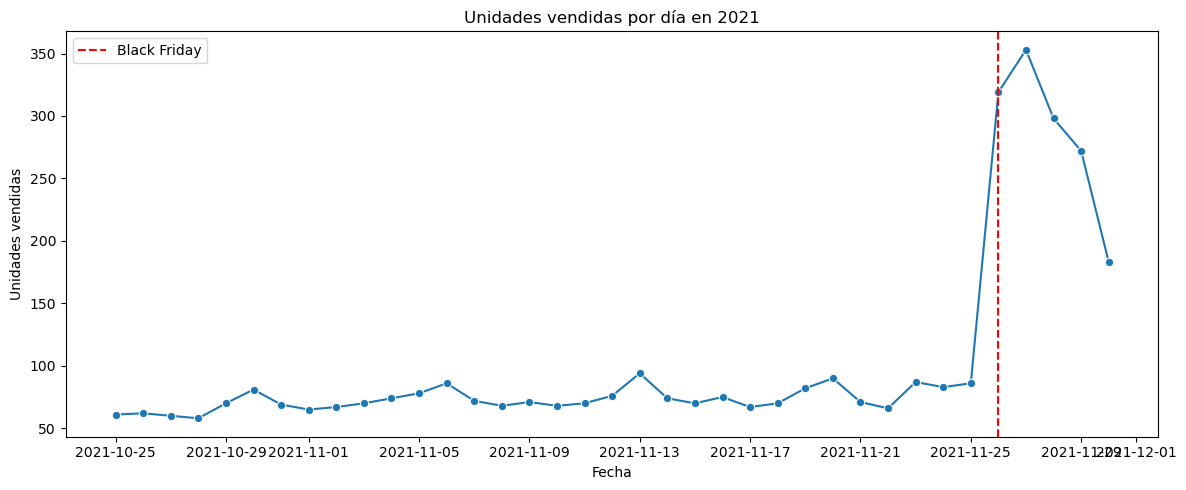

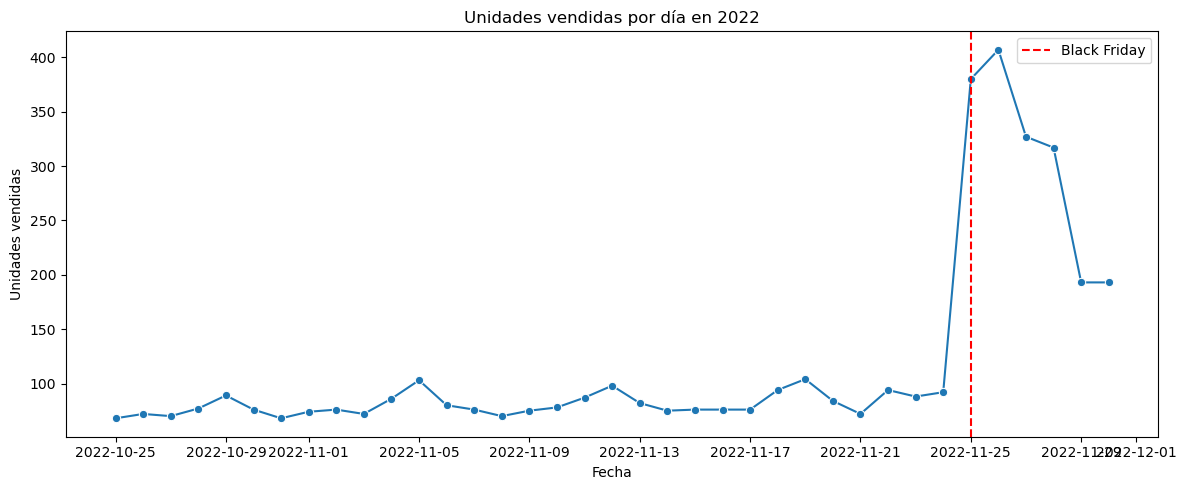

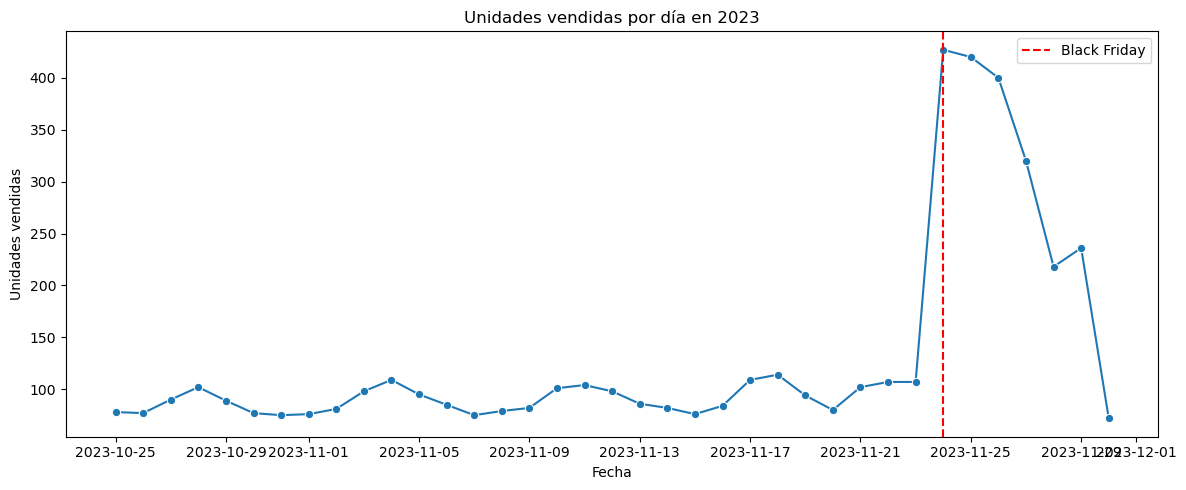

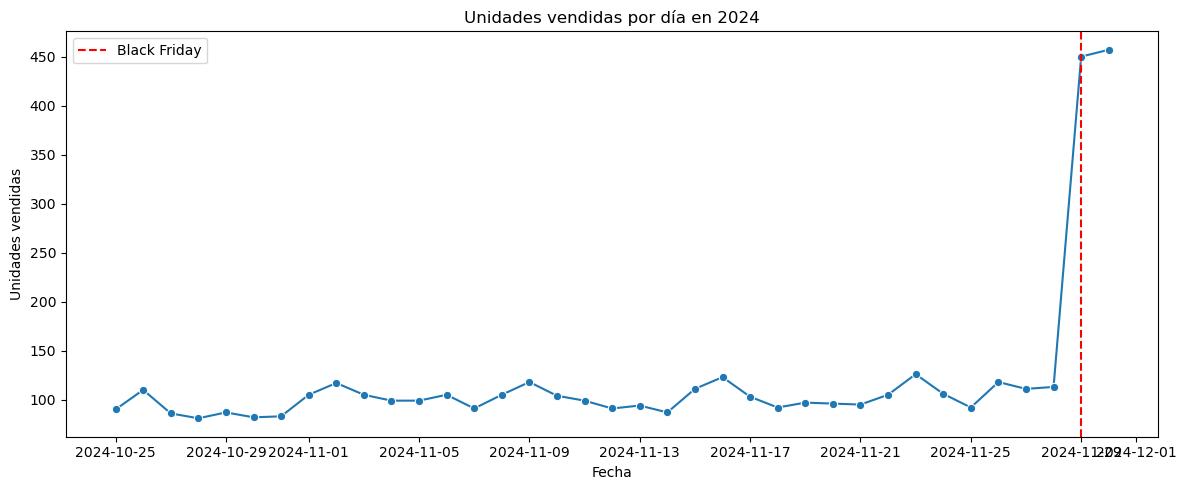

In [51]:
# Gráfico de líneas por año
for year in sorted(df['año'].unique()):
    plt.figure(figsize=(12,5))
    datos = df[df['año'] == year].groupby('fecha')['unidades_vendidas'].sum()
    sns.lineplot(x=datos.index, y=datos.values, marker='o')
    plt.title(f'Unidades vendidas por día en {year}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    # Marcar Black Friday
    bf = [d for d in black_fridays if d.year == year]
    for b in bf:
        plt.axvline(b, color='red', linestyle='--', label='Black Friday')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2. Unidades vendidas por día de la semana

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\1904644031.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='dia_semana', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\1904644031.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dia_semana', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='viridis')


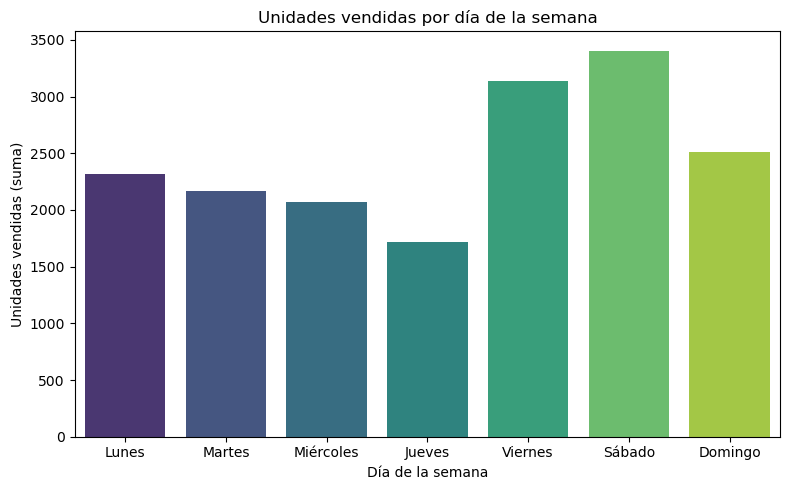

In [52]:
# Gráfico de suma de unidades vendidas por día de la semana
plt.figure(figsize=(8,5))
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orden_dias_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['dia_semana_es'] = df['fecha'].dt.day_name(locale='es_ES')
df['dia_semana'] = pd.Categorical(df['dia_semana_es'], categories=orden_dias_es, ordered=True)
sns.barplot(x='dia_semana', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas (suma)')
plt.tight_layout()
plt.show()

### 3. Unidades vendidas por categoría

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\2478153780.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='categoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='crest', order=df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\2478153780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='crest', order=df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)


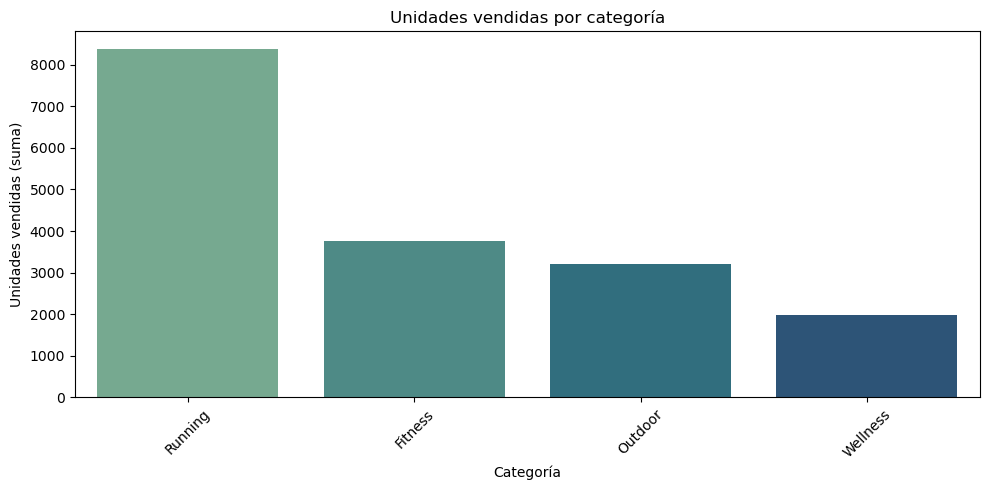

In [53]:
# Gráfico de suma de unidades vendidas por categoría
plt.figure(figsize=(10,5))
sns.barplot(x='categoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='crest', order=df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)
plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas (suma)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. Unidades vendidas por subcategoría

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\685114.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='subcategoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='mako', order=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\685114.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='subcategoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='mako', order=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)


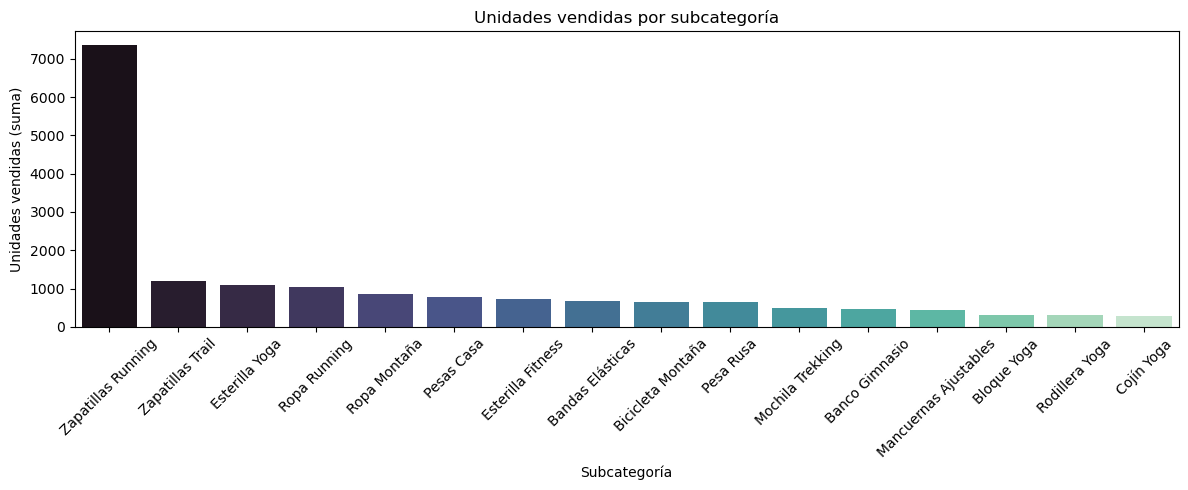

In [54]:
# Gráfico de suma de unidades vendidas por subcategoría
plt.figure(figsize=(12,5))
sns.barplot(x='subcategoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, palette='mako', order=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas (suma)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Unidades vendidas por top productos

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\2649343962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos.index, y=top_productos.values, palette='flare')


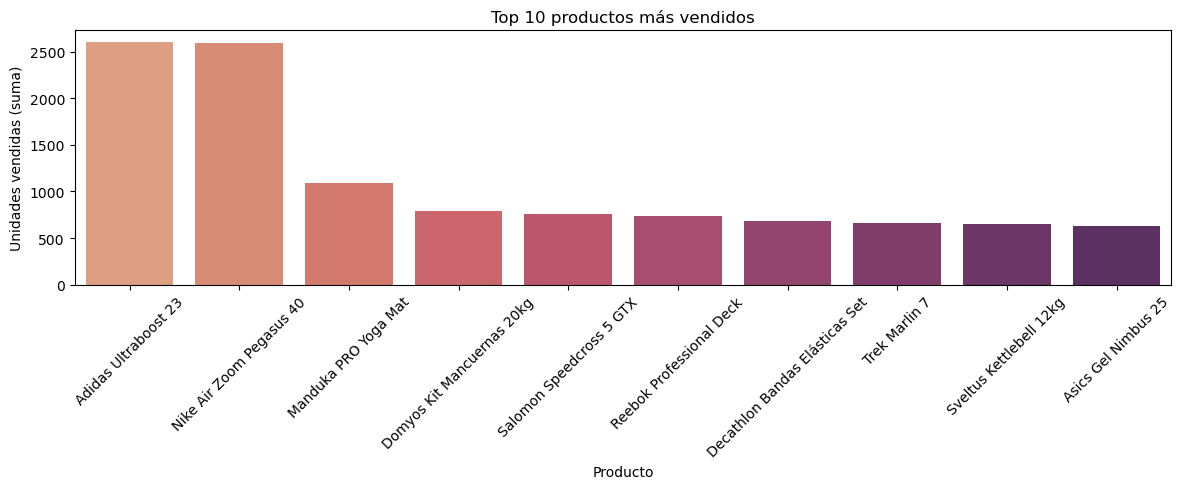

In [55]:
# Gráfico de los top 10 productos más vendidos
plt.figure(figsize=(12,5))
top_n = 10
top_productos = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(top_n)
sns.barplot(x=top_productos.index, y=top_productos.values, palette='flare')
plt.title(f'Top {top_n} productos más vendidos')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas (suma)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Densidad de distribución de precios propios y de Amazon

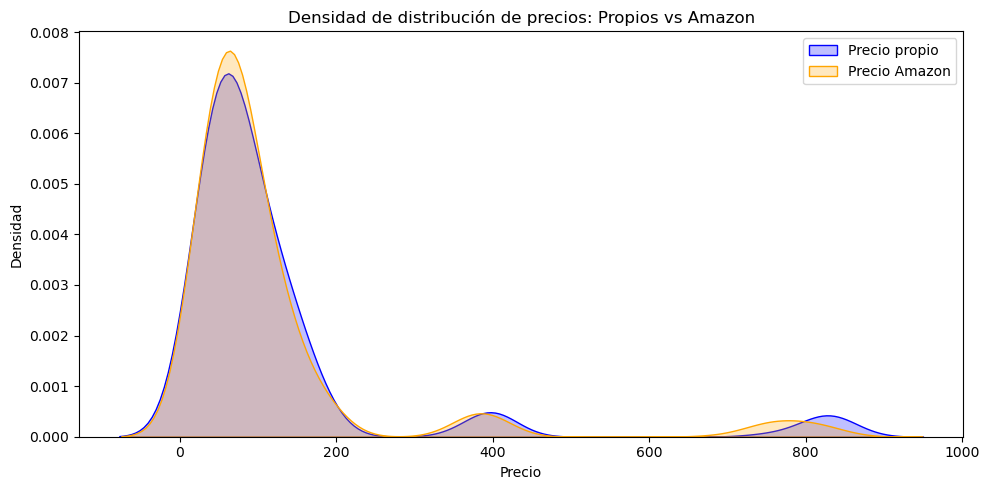

In [56]:
# Densidad de precios propios y de Amazon
plt.figure(figsize=(10,5))
sns.kdeplot(df['precio_venta'], label='Precio propio', fill=True, color='blue')
sns.kdeplot(competencia_df['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de distribución de precios: Propios vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
# ========================
# Creación de variables temporales en df
# ========================
import holidays

# Año, mes, día del mes, día de la semana
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia_semana'] = df['fecha'].dt.day_name(locale='es_ES')

# Es fin de semana
df['es_fin_de_semana'] = df['dia_semana'].isin([5, 6])

# Festivos en España
festivos_es = holidays.country_holidays('ES', years=df['año'].unique())
df['es_festivo'] = df['fecha'].isin(festivos_es)

# Black Friday (último viernes de noviembre)
def es_black_friday(fecha):
    if fecha.month == 11 and fecha.weekday() == 4:
        # Último viernes de noviembre
        ultimo_viernes = max([d for d in pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30') if d.weekday() == 4])
        return fecha == ultimo_viernes
    return False
df['es_black_friday'] = df['fecha'].apply(es_black_friday)

# Cyber Monday (primer lunes después de Black Friday)
def es_cyber_monday(fecha):
    if fecha.month == 11 or fecha.month == 12:
        # Buscar el Black Friday de ese año
        black_friday = max([d for d in pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30') if d.weekday() == 4])
        cyber_monday = black_friday + pd.Timedelta(days=3)
        return fecha == cyber_monday
    return False
df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday)

# Día laborable (no fin de semana ni festivo)
df['es_laborable'] = (~df['es_fin_de_semana']) & (~df['es_festivo'])

# Semana del año
df['semana_año'] = df['fecha'].dt.isocalendar().week

# Día del año
df['dia_año'] = df['fecha'].dt.dayofyear

# Primer/último día del mes
df['es_primer_dia_mes'] = df['dia_mes'] == 1
df['es_ultimo_dia_mes'] = df['fecha'] == (df['fecha'] + pd.offsets.MonthEnd(0))

# Trimestre
df['trimestre'] = df['fecha'].dt.quarter

# Mitad del mes (True si es del 1 al 15)
df['es_primer_quincena'] = df['dia_mes'] <= 15

# Día previo a festivo
df['es_víspera_festivo'] = (df['fecha'] + pd.Timedelta(days=1)).isin(festivos_es)

# Día posterior a festivo
df['es_post_festivo'] = (df['fecha'] - pd.Timedelta(days=1)).isin(festivos_es)

# Mostrar las primeras filas para verificar
df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\1616993215.py:18: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(festivos_es)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\1616993215.py:59: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_víspera_festivo'] = (df['fecha'] + pd.Timedelta(days=1)).isin(festivos_es)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21580\1616993215.py:62: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not b

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_cyber_monday,es_laborable,semana_año,dia_año,es_primer_dia_mes,es_ultimo_dia_mes,trimestre,es_primer_quincena,es_víspera_festivo,es_post_festivo
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,True,43,298,False,False,4,False,False,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,False,True,43,298,False,False,4,False,False,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,False,True,43,298,False,False,4,False,False,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,True,43,298,False,False,4,False,False,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,True,43,298,False,False,4,False,False,False


In [79]:
df.shape

(3524, 37)

In [78]:
# ========================
# Creación de lags y media móvil de 7 días para unidades_vendidas
# ========================
# Ordenar por año y fecha para evitar mezclas entre años
df = df.sort_values(['año', 'fecha']).reset_index(drop=True)

# Crear lags del 1 al 7 y media móvil de 7 días por año
for lag in range(1, 8):
    df[f'unidades_vendidas_lag{lag}'] = df.groupby('año')['unidades_vendidas'].shift(lag)

df['unidades_vendidas_mm7'] = df.groupby('año')['unidades_vendidas'].transform(lambda x: x.rolling(window=7, min_periods=7).mean())

# Eliminar registros con nulos en los nuevos lags o media móvil
cols_lags = [f'unidades_vendidas_lag{i}' for i in range(1,8)] + ['unidades_vendidas_mm7']
df = df.dropna(subset=cols_lags).reset_index(drop=True)

# Mostrar las primeras filas para verificar
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_víspera_festivo,es_post_festivo,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
0,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,False,False,2.0,2.0,2.0,2.0,2.0,10.0,6.0,3.142857
1,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,False,False,2.0,2.0,2.0,2.0,2.0,2.0,10.0,2.000000
2,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,False,False,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.000000
3,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,False,False,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.142857
4,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,False,False,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.285714


In [91]:
# ========================
# Variables de precio competencia y ratio de precio
# ========================
# Recuperar las columnas de competencia desde competencia_df si no están en df
if not set(['Amazon', 'Decathlon', 'Deporvillage']).issubset(df.columns):
    df = pd.merge(df, competencia_df[['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage']], on=['fecha', 'producto_id'], how='left', suffixes=('', '_comp'))

# Calcular el precio promedio de la competencia solo si existen las columnas
compet_cols = [col for col in ['Amazon', 'Decathlon', 'Deporvillage'] if col in df.columns]
if len(compet_cols) == 3:
    df['precio_competencia'] = df[compet_cols].mean(axis=1)
    df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']
    df = df.drop(columns=compet_cols)
else:
    print('No se encontraron todas las columnas de competencia necesarias.')

# Mostrar las primeras filas para verificar si se crearon las variables
df[['precio_venta', 'precio_competencia', 'ratio_precio']].head()

,precio_venta,precio_competencia,ratio_precio
0,66.60,64.346667,1.035019
1,392.31,350.850000,1.118170
2,174.92,160.156667,1.092181
3,44.32,44.563333,0.994540
4,55.05,53.246667,1.033868


In [92]:
# ========================
# Variables de precio competencia y ratio de precio (versión robusta)
# ========================
# Recuperar las columnas de competencia desde competencia_df si no están en df
compet_cols = [col for col in ['Amazon', 'Decathlon', 'Deporvillage'] if col in df.columns]
if len(compet_cols) < 3:
    # Solo unir si falta alguna columna
    df = pd.merge(df, competencia_df[['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage']], on=['fecha', 'producto_id'], how='left', suffixes=('', '_comp'))
    compet_cols = [col for col in ['Amazon', 'Decathlon', 'Deporvillage'] if col in df.columns]

if len(compet_cols) == 3:
    df['precio_competencia'] = df[compet_cols].mean(axis=1)
    df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']
    df = df.drop(columns=compet_cols)
    # Mostrar las primeras filas para verificar si se crearon las variables
    display_cols = ['precio_venta', 'precio_competencia', 'ratio_precio']
    print(df[display_cols].head())
else:
    print('No se encontraron todas las columnas de competencia necesarias.')

   precio_venta  precio_competencia  ratio_precio
0         66.60           64.346667      1.035019
1        392.31          350.850000      1.118170
2        174.92          160.156667      1.092181
3         44.32           44.563333      0.994540
4         55.05           53.246667      1.033868


In [94]:
# ========================
# Copia de variables categóricas y one hot encoding
# ========================
# Crear copias con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One hot encoding sobre las nuevas variables
df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], prefix=['nombre_h', 'categoria_h', 'subcategoria_h'])

# Mostrar las primeras columnas para verificar
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,False,False,False,False,False,False,False,False,True,False
1,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,False,True,False,False,False,False,False,False,False,False
2,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,False,False,False,False,False,False,False,False,False,False
3,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,False,False,False,False,False,False,False,False,False,False
4,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,False,False,False,False,True,False,False,False,False,False


In [99]:
# ========================
# Guardar el dataframe df en la carpeta data/processed
# ========================
df.to_csv('../data/processed/df.csv', index=False)

In [100]:
# ========================
# División en train y validation por año
# ========================
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print(f'Registros en train_df: {len(train_df)}')
print(f'Registros en validation_df: {len(validation_df)}')

Registros en train_df: 2643
Registros en validation_df: 881


In [102]:
# ========================
# Entrenamiento HistGradientBoostingRegressor y comparación con baseline
# ========================
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selección de variables predictoras (excluyendo fecha, ingresos y tipo object)
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols = [col for col in train_df.columns if col not in excluir and train_df[col].dtype != 'O']

X_train = train_df[X_cols]
y_train = train_df['unidades_vendidas']
X_val = validation_df[X_cols]
y_val = validation_df['unidades_vendidas']

# Modelo conservador para evitar overfitting
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)

model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: predice la media de train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
def forecasting_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

mae, rmse, mape, r2 = forecasting_metrics(y_val, y_pred)
mae_naive, rmse_naive, mape_naive, r2_naive = forecasting_metrics(y_val, y_pred_naive)

print('HistGradientBoostingRegressor:')
print(f'MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R2: {r2:.3f}')
print('Baseline Naive (media):')
print(f'MAE: {mae_naive:.2f} | RMSE: {rmse_naive:.2f} | MAPE: {mape_naive:.2f}% | R2: {r2_naive:.3f}')

HistGradientBoostingRegressor:
MAE: 0.71 | RMSE: 1.50 | MAPE: 16.09% | R2: 0.942
Baseline Naive (media):
MAE: 3.34 | RMSE: 6.25 | MAPE: 86.67% | R2: -0.000


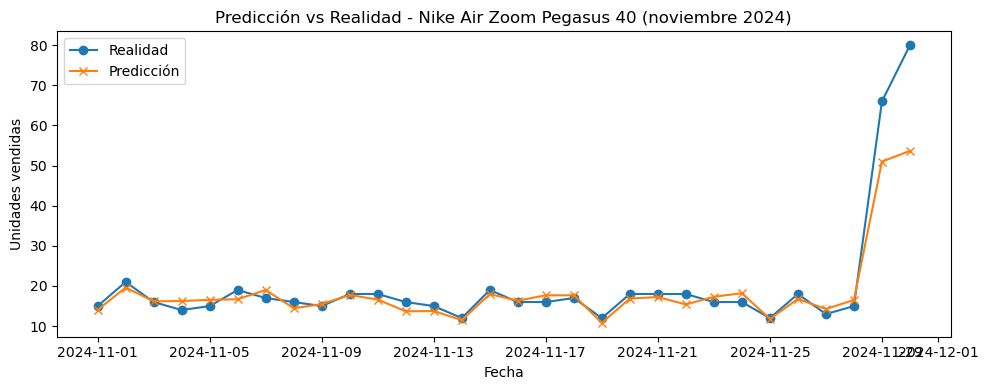

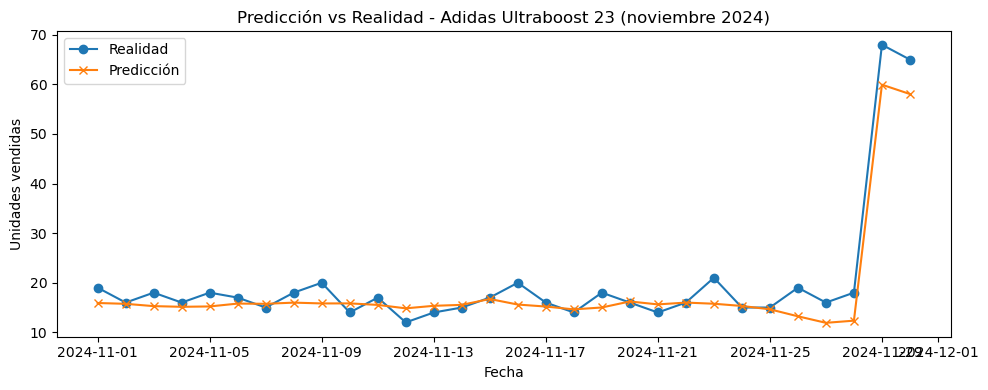

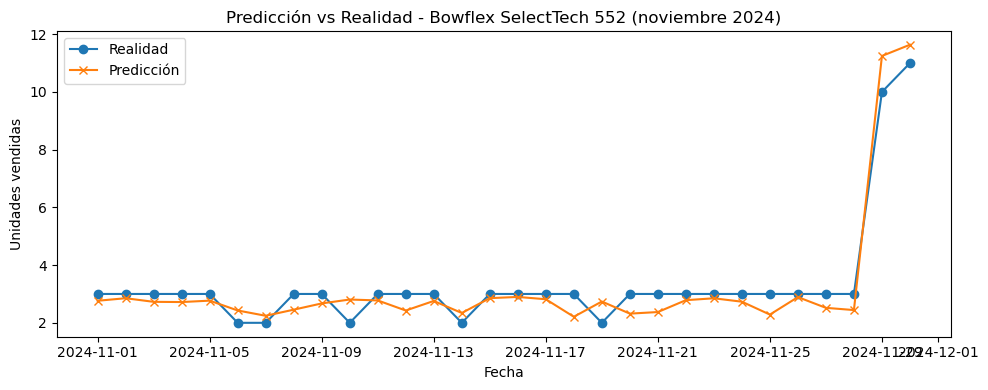

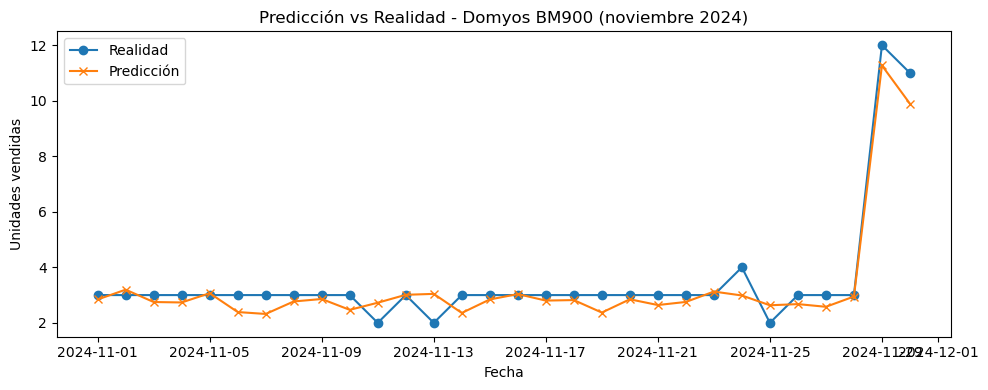

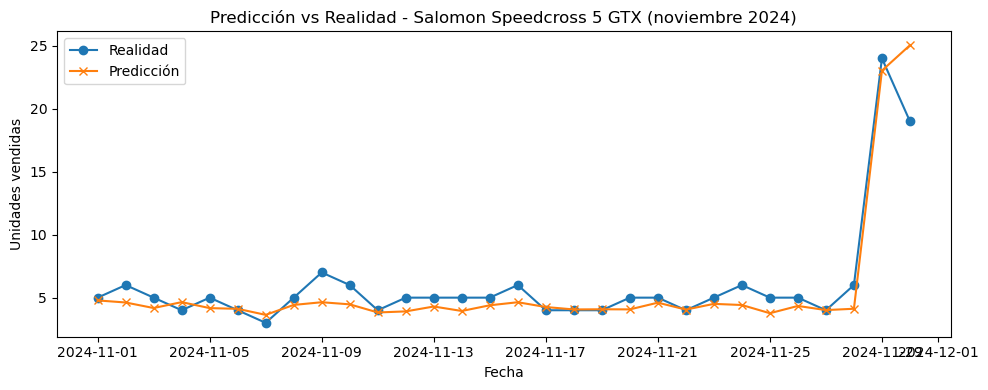

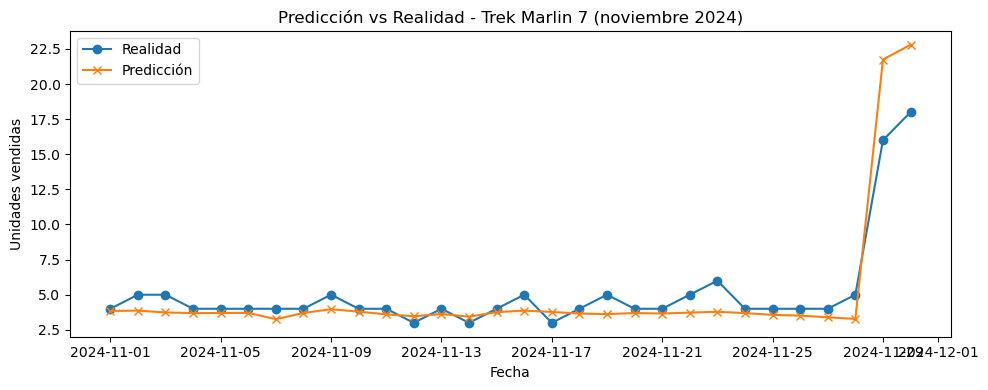

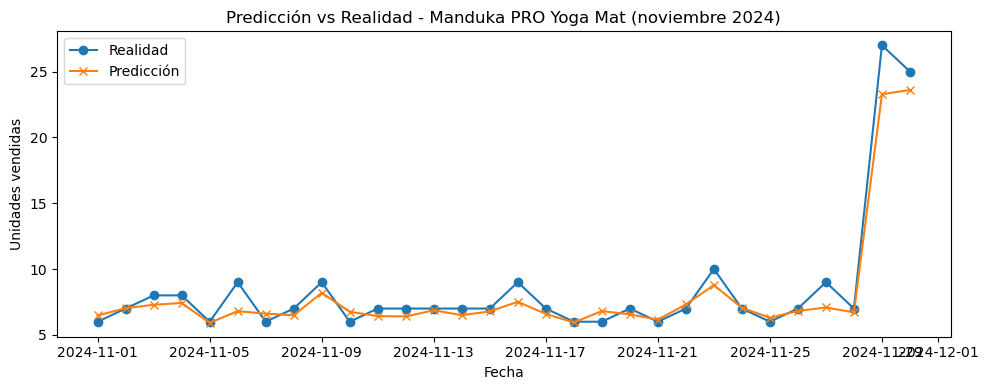

In [103]:
# ========================
# Predicción y visualización para productos estrella en noviembre 2024
# ========================
import matplotlib.pyplot as plt

# Filtrar noviembre 2024 y productos estrella
nov2024 = validation_df[(validation_df['año'] == 2024) & (validation_df['mes'] == 11) & (validation_df['es_estrella'] == 1)]

# Obtener los nombres de los 7 productos estrella
productos_estrella = nov2024['nombre'].unique()[:7]

for producto in productos_estrella:
    df_prod = nov2024[nov2024['nombre'] == producto].copy()
    X_prod = df_prod[X_cols]
    y_real = df_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    plt.figure(figsize=(10,4))
    plt.plot(df_prod['fecha'], y_real, label='Realidad', marker='o')
    plt.plot(df_prod['fecha'], y_pred, label='Predicción', marker='x')
    plt.title(f'Predicción vs Realidad - {producto} (noviembre 2024)')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [104]:
# ========================
# MAE para cada producto estrella en noviembre 2024
# ========================
from sklearn.metrics import mean_absolute_error

mae_dict = {}
for producto in productos_estrella:
    df_prod = nov2024[nov2024['nombre'] == producto].copy()
    X_prod = df_prod[X_cols]
    y_real = df_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    mae = mean_absolute_error(y_real, y_pred)
    mae_dict[producto] = mae

print('MAE por producto estrella en noviembre 2024:')
for producto, mae in mae_dict.items():
    print(f'{producto}: MAE = {mae:.2f}')

MAE por producto estrella en noviembre 2024:
Nike Air Zoom Pegasus 40: MAE = 2.56
Adidas Ultraboost 23: MAE = 2.44
Bowflex SelectTech 552: MAE = 0.42
Domyos BM900: MAE = 0.40
Salomon Speedcross 5 GTX: MAE = 0.96
Trek Marlin 7: MAE = 0.98
Manduka PRO Yoga Mat: MAE = 0.72


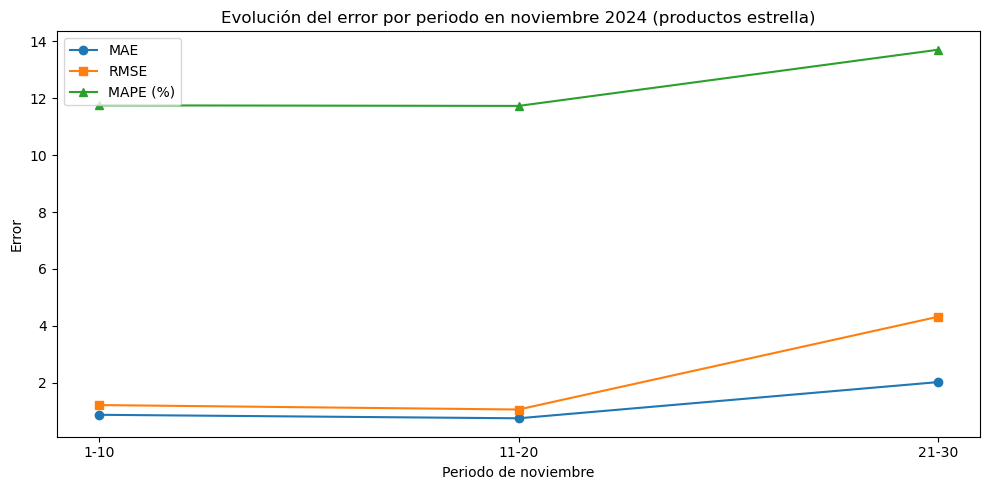

  periodo       MAE      RMSE       MAPE
0    1-10  0.868793  1.211372  11.753356
1   11-20  0.745794  1.054251  11.733118
2   21-30  2.018982  4.316529  13.708171


In [105]:
# ========================
# Análisis de degradación del error por periodos de 10 días en noviembre 2024
# ========================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Añadir columna de periodo a nov2024
nov2024 = nov2024.copy()
nov2024['periodo'] = pd.cut(nov2024['dia_mes'], bins=[0,10,20,31], labels=['1-10','11-20','21-30'])

# Calcular métricas por periodo para todos los productos estrella juntos
resultados = []
for periodo in ['1-10','11-20','21-30']:
    df_per = nov2024[nov2024['periodo'] == periodo]
    if len(df_per) == 0: continue
    X_per = df_per[X_cols]
    y_real = df_per['unidades_vendidas']
    y_pred = model.predict(X_per)
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    resultados.append({'periodo': periodo, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})

# Convertir a DataFrame para graficar
import pandas as pd
df_resultados = pd.DataFrame(resultados)

# Graficar evolución del error
plt.figure(figsize=(10,5))
plt.plot(df_resultados['periodo'], df_resultados['MAE'], marker='o', label='MAE')
plt.plot(df_resultados['periodo'], df_resultados['RMSE'], marker='s', label='RMSE')
plt.plot(df_resultados['periodo'], df_resultados['MAPE'], marker='^', label='MAPE (%)')
plt.title('Evolución del error por periodo en noviembre 2024 (productos estrella)')
plt.xlabel('Periodo de noviembre')
plt.ylabel('Error')
plt.legend()
plt.tight_layout()
plt.show()

print(df_resultados)

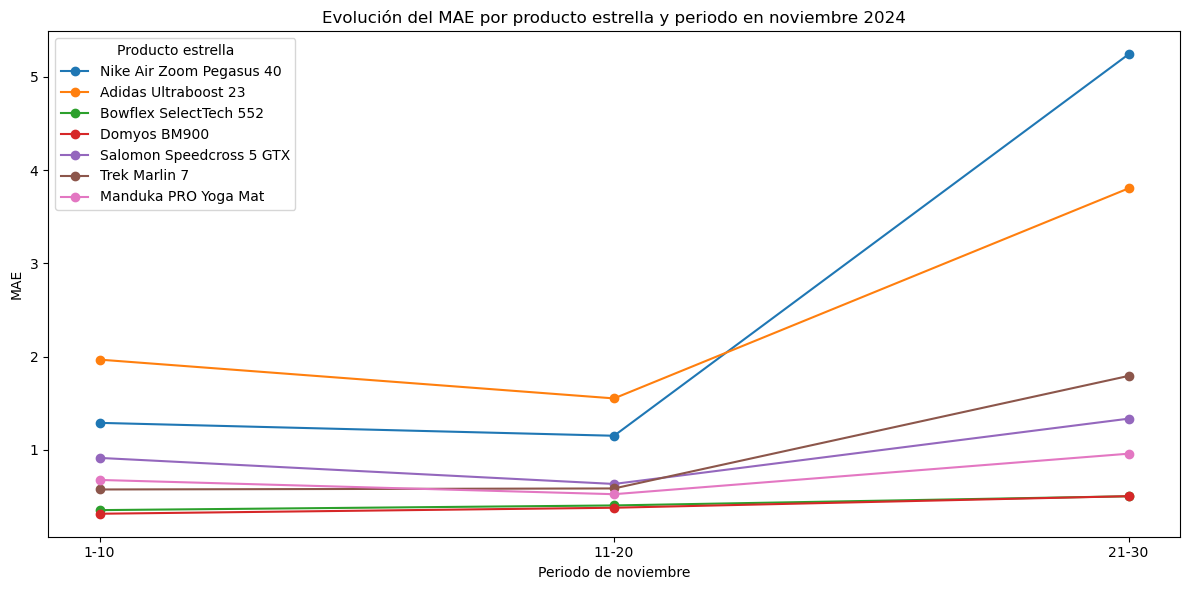

                    producto periodo       MAE
0   Nike Air Zoom Pegasus 40    1-10  1.288361
1   Nike Air Zoom Pegasus 40   11-20  1.149966
2   Nike Air Zoom Pegasus 40   21-30  5.243363
3       Adidas Ultraboost 23    1-10  1.966880
4       Adidas Ultraboost 23   11-20  1.550721
5       Adidas Ultraboost 23   21-30  3.804593
6     Bowflex SelectTech 552    1-10  0.351928
7     Bowflex SelectTech 552   11-20  0.402189
8     Bowflex SelectTech 552   21-30  0.500646
9               Domyos BM900    1-10  0.312996
10              Domyos BM900   11-20  0.377525
11              Domyos BM900   21-30  0.501529
12  Salomon Speedcross 5 GTX    1-10  0.912160
13  Salomon Speedcross 5 GTX   11-20  0.632738
14  Salomon Speedcross 5 GTX   21-30  1.333300
15             Trek Marlin 7    1-10  0.573459
16             Trek Marlin 7   11-20  0.584578
17             Trek Marlin 7   21-30  1.791991
18      Manduka PRO Yoga Mat    1-10  0.675765
19      Manduka PRO Yoga Mat   11-20  0.522838
20      Mandu

In [106]:
# ========================
# Evolución del MAE por producto estrella y periodo en noviembre 2024
# ========================
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
mae_periodo_producto = []
for producto in productos_estrella:
    df_prod = nov2024[nov2024['nombre'] == producto].copy()
    for periodo in ['1-10','11-20','21-30']:
        df_per = df_prod[df_prod['periodo'] == periodo]
        if len(df_per) == 0: continue
        X_per = df_per[X_cols]
        y_real = df_per['unidades_vendidas']
        y_pred = model.predict(X_per)
        mae = mean_absolute_error(y_real, y_pred)
        mae_periodo_producto.append({'producto': producto, 'periodo': periodo, 'MAE': mae})
df_mae = pd.DataFrame(mae_periodo_producto)
plt.figure(figsize=(12,6))
for producto in productos_estrella:
    df_p = df_mae[df_mae['producto'] == producto]
    plt.plot(df_p['periodo'], df_p['MAE'], marker='o', label=producto)
plt.title('Evolución del MAE por producto estrella y periodo en noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('MAE')
plt.legend(title='Producto estrella')
plt.tight_layout()
plt.show()
print(df_mae)

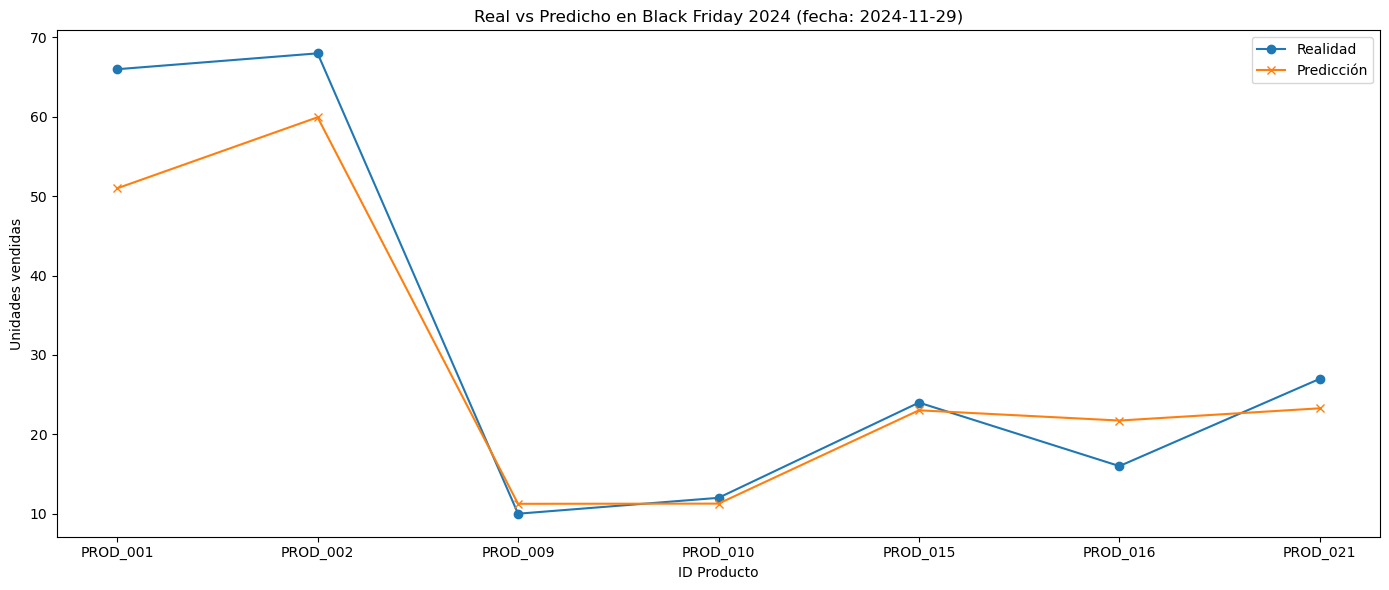

     producto_id  real   predicho
3476    PROD_001    66  50.996362
3477    PROD_002    68  59.944888
3484    PROD_009    10  11.247500
3485    PROD_010    12  11.270496
3490    PROD_015    24  23.027454
3491    PROD_016    16  21.737277
3496    PROD_021    27  23.279904


In [107]:
# ========================
# Análisis específico de Black Friday 2024: Real vs Predicho por producto
# ========================
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
black_friday_fecha = nov2024[nov2024['es_black_friday'] == True]['fecha'].unique()
if len(black_friday_fecha) > 0:
    bf_fecha = black_friday_fecha[0]
    df_bf = nov2024[nov2024['fecha'] == bf_fecha].copy()
    X_bf = df_bf[X_cols]
    y_real = df_bf['unidades_vendidas']
    y_pred = model.predict(X_bf)
    producto_ids = df_bf['producto_id']
    plt.figure(figsize=(14,6))
    plt.plot(producto_ids, y_real, marker='o', label='Realidad')
    plt.plot(producto_ids, y_pred, marker='x', label='Predicción')
    plt.title(f'Real vs Predicho en Black Friday 2024 (fecha: {bf_fecha.date()})')
    plt.xlabel('ID Producto')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Mostrar tabla de resultados
    resultados_bf = pd.DataFrame({'producto_id': producto_ids, 'real': y_real, 'predicho': y_pred})
    print(resultados_bf)
else:
    print('No se encontró registro de Black Friday en noviembre 2024.')

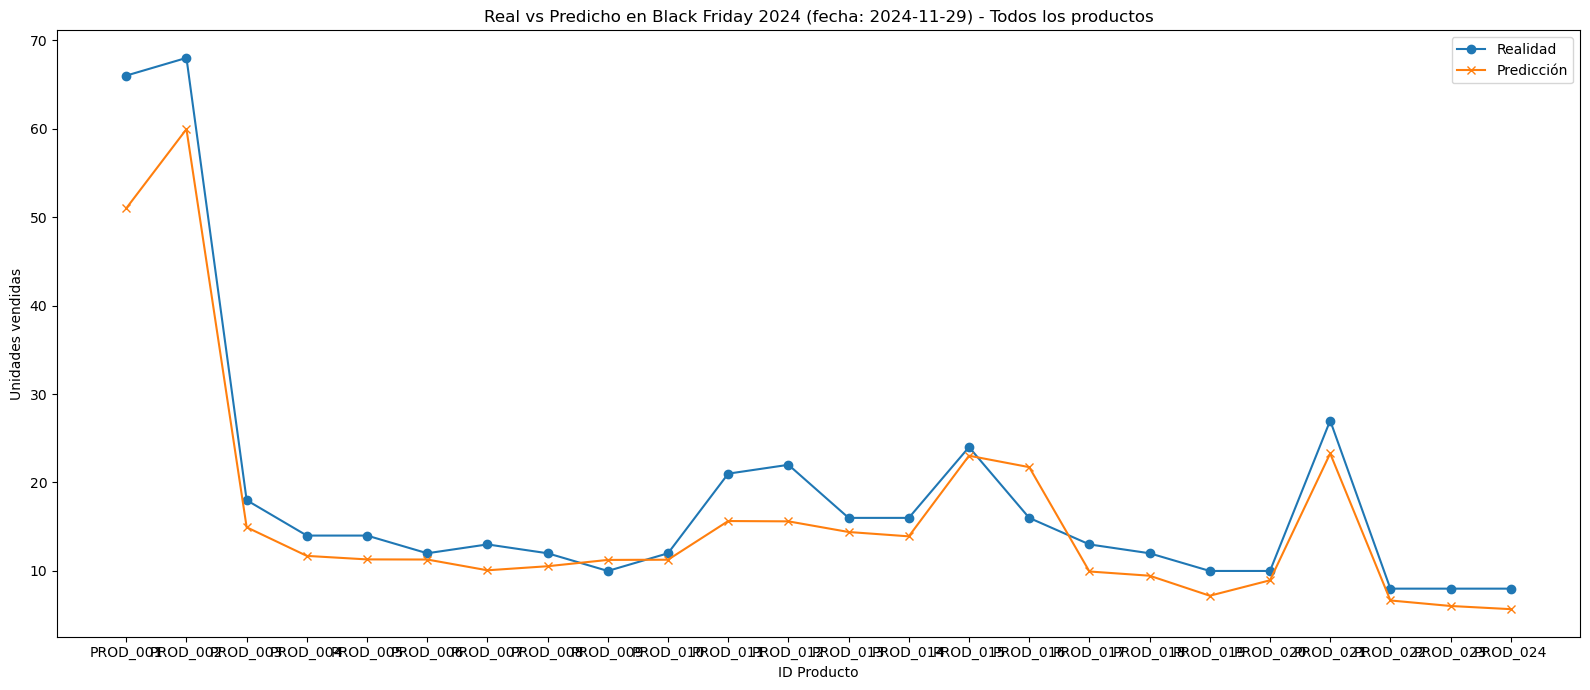

     producto_id  real   predicho
3476    PROD_001    66  50.996362
3477    PROD_002    68  59.944888
3478    PROD_003    18  14.938808
3479    PROD_004    14  11.703143
3480    PROD_005    14  11.305611
3481    PROD_006    12  11.292327
3482    PROD_007    13  10.074740
3483    PROD_008    12  10.534827
3484    PROD_009    10  11.247500
3485    PROD_010    12  11.270496
3486    PROD_011    21  15.643240
3487    PROD_012    22  15.606738
3488    PROD_013    16  14.403837
3489    PROD_014    16  13.913577
3490    PROD_015    24  23.027454
3491    PROD_016    16  21.737277
3492    PROD_017    13   9.939177
3493    PROD_018    12   9.461800
3494    PROD_019    10   7.199063
3495    PROD_020    10   8.943258
3496    PROD_021    27  23.279904
3497    PROD_022     8   6.664162
3498    PROD_023     8   6.040246
3499    PROD_024     8   5.681137


In [108]:
# ========================
# Black Friday 2024: Real vs Predicho para TODOS los productos
# ========================
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
black_friday_fecha = validation_df[(validation_df['mes'] == 11) & (validation_df['es_black_friday'] == True)]['fecha'].unique()
if len(black_friday_fecha) > 0:
    bf_fecha = black_friday_fecha[0]
    df_bf = validation_df[validation_df['fecha'] == bf_fecha].copy()
    X_bf = df_bf[X_cols]
    y_real = df_bf['unidades_vendidas']
    y_pred = model.predict(X_bf)
    producto_ids = df_bf['producto_id']
    plt.figure(figsize=(16,7))
    plt.plot(producto_ids, y_real, marker='o', label='Realidad')
    plt.plot(producto_ids, y_pred, marker='x', label='Predicción')
    plt.title(f'Real vs Predicho en Black Friday 2024 (fecha: {bf_fecha.date()}) - Todos los productos')
    plt.xlabel('ID Producto')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Mostrar tabla de resultados
    resultados_bf = pd.DataFrame({'producto_id': producto_ids, 'real': y_real, 'predicho': y_pred})
    print(resultados_bf)
else:
    print('No se encontró registro de Black Friday en noviembre 2024.')

In [109]:
# ========================
# Reentrenamiento final del modelo con todos los datos históricos (2021-2024)
# ========================
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
final_X = df[X_cols]
final_y = df['unidades_vendidas']
final_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
final_model.fit(final_X, final_y)
print('Modelo final entrenado con todos los datos históricos (2021-2024).')

Modelo final entrenado con todos los datos históricos (2021-2024).


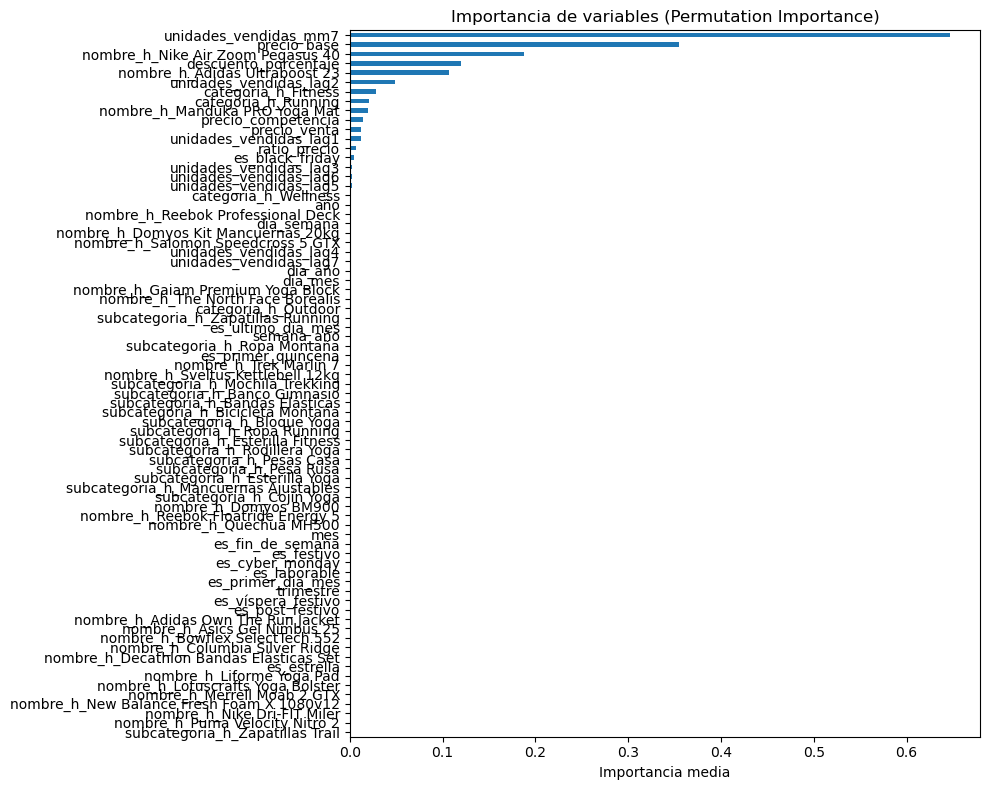

Modelo final guardado en ../models/modelo_final.joblib


In [110]:
# ========================
# Importancia de variables (Permutation Importance) y guardado del modelo final
# ========================
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
# Calcular permutation importance sobre el conjunto de entrenamiento completo
result = permutation_importance(final_model, final_X, final_y, n_repeats=10, random_state=42, n_jobs=-1)
importancias = pd.Series(result.importances_mean, index=X_cols)
importancias = importancias.sort_values(ascending=False)
# Gráfico de barras horizontales
plt.figure(figsize=(10,8))
importancias.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Importancia de variables (Permutation Importance)')
plt.xlabel('Importancia media')
plt.tight_layout()
plt.show()
# Guardar el modelo final
joblib.dump(final_model, '../models/modelo_final.joblib')
print('Modelo final guardado en ../models/modelo_final.joblib')